# aule — Plots

This notebook walks through every plotting function in `aule.plots`. All plots return `(fig, ax)` (or `(fig, axes)` for multi-panel plots), so you can keep customizing them after the call, and all of them accept an optional `save_path` to auto-save to disk.

In [ ]:
!pip install aule

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

gt   = np.random.rand(8, 64, 64, 1)        # (batch, H, W, C)
pred = gt + np.random.normal(0, 0.1, gt.shape)

## Core distribution plots

`plot_scatter`, `plot_qq`, `plot_histogram_comparison`, `plot_error_histogram` — these work on the flattened values, regardless of spatial structure.

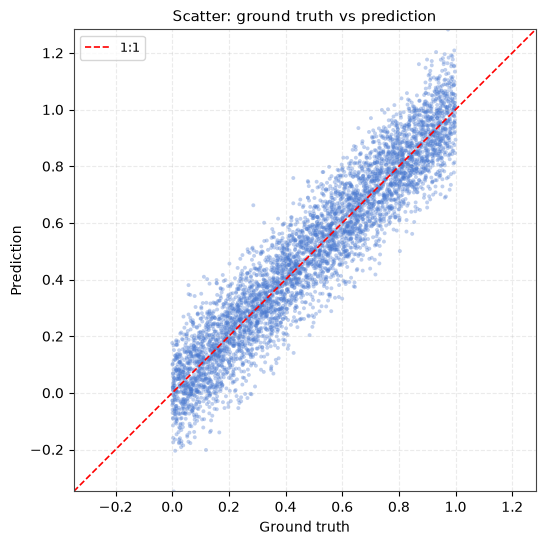

In [2]:
from aule.plots import plot_scatter

fig, ax = plot_scatter(gt, pred, save_path='scatter.png')

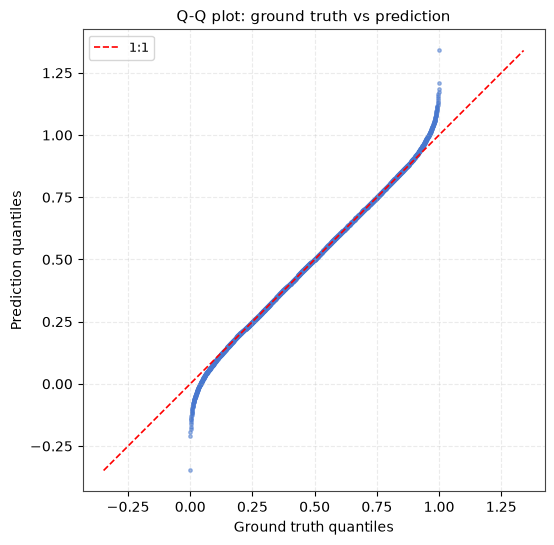

In [3]:
from aule.plots import plot_qq

fig, ax = plot_qq(gt, pred)

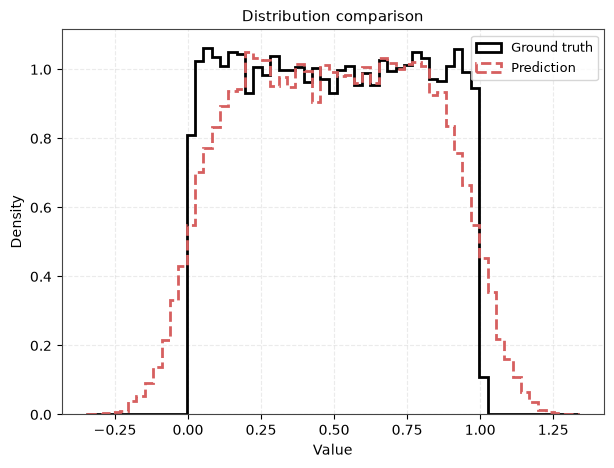

In [4]:
from aule.plots import plot_histogram_comparison

fig, ax = plot_histogram_comparison(gt, pred)

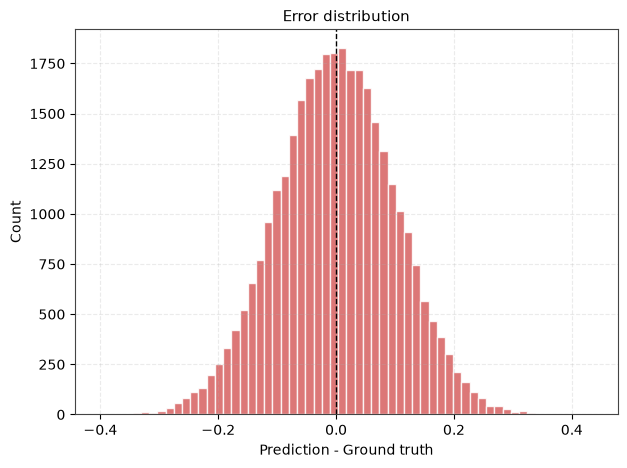

In [5]:
from aule.plots import plot_error_histogram

fig, ax = plot_error_histogram(gt, pred)

## Spatial map plots

`plot_field_comparison`, `plot_bias_map`, `plot_correlation_map` — these show single 2D slices. They also accept optional `lat`/`lon` 2D arrays to draw a cartopy geographic basemap (requires the optional `aule[geo]` dependency); without them, they fall back to a plain `imshow`, as shown here.

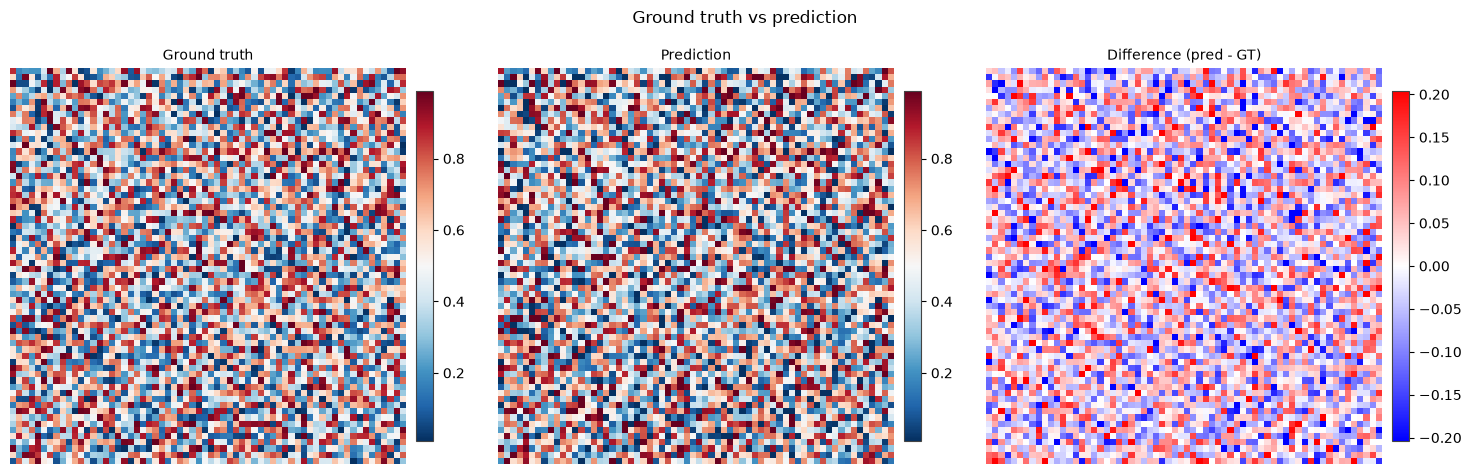

In [6]:
from aule.plots import plot_field_comparison

fig, axes = plot_field_comparison(gt, pred, batch_index=0)

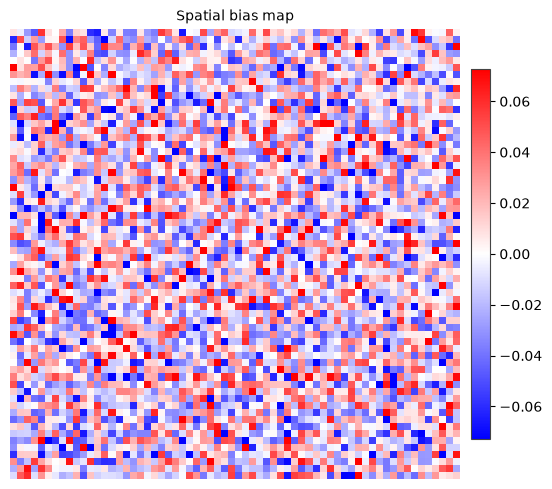

In [7]:
from aule.plots import plot_bias_map

fig, ax = plot_bias_map(gt, pred)  # averaged over the batch axis

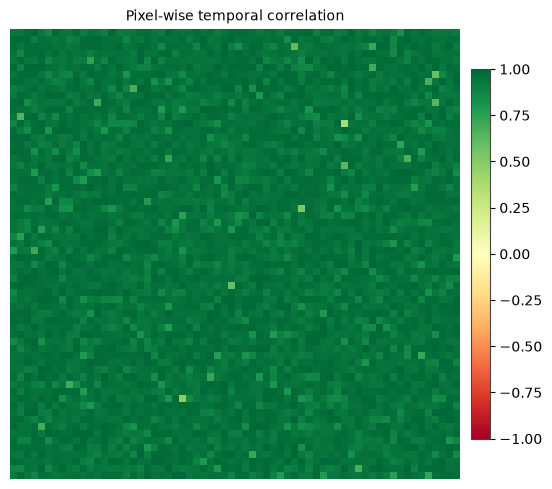

In [8]:
from aule.plots import plot_correlation_map
from aule.metrics import pixelwise_temporal_correlation

r_map = pixelwise_temporal_correlation(gt, pred)
fig, ax = plot_correlation_map(r_map)

## Climate plots

`plot_temporal_trend` and `plot_temporal_scatter` operate on a time axis (here we use the batch axis as a stand-in time dimension for the demo).

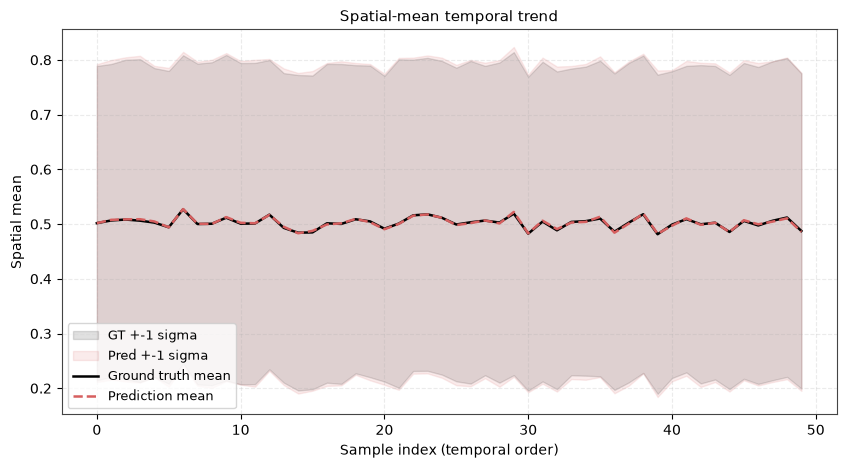

In [9]:
from aule.plots import plot_temporal_trend

gt_t = np.random.rand(32, 32, 1, 50)
pred_t = gt_t + np.random.normal(0, 0.05, gt_t.shape)

fig, ax = plot_temporal_trend(gt_t, pred_t, data_format='hwct')

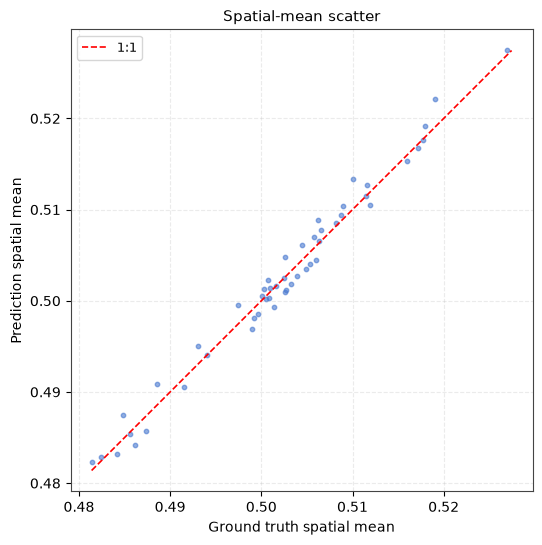

In [10]:
from aule.plots import plot_temporal_scatter

fig, ax = plot_temporal_scatter(gt_t, pred_t, data_format='hwct')

## Ensemble plots

`plot_ensemble_spread_map` shows the spatial pattern of ensemble uncertainty; `plot_rank_histogram` is the visual companion to `aule.metrics.rank_histogram`.

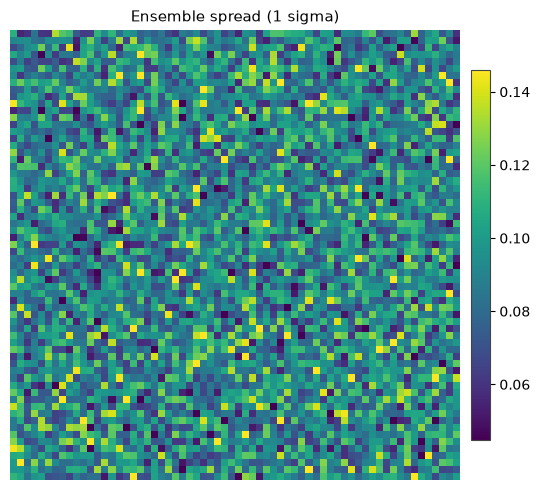

In [11]:
ensemble = gt[0][np.newaxis] + np.random.normal(0, 0.1, (10, 64, 64, 1))

from aule.plots import plot_ensemble_spread_map

fig, ax = plot_ensemble_spread_map(ensemble)

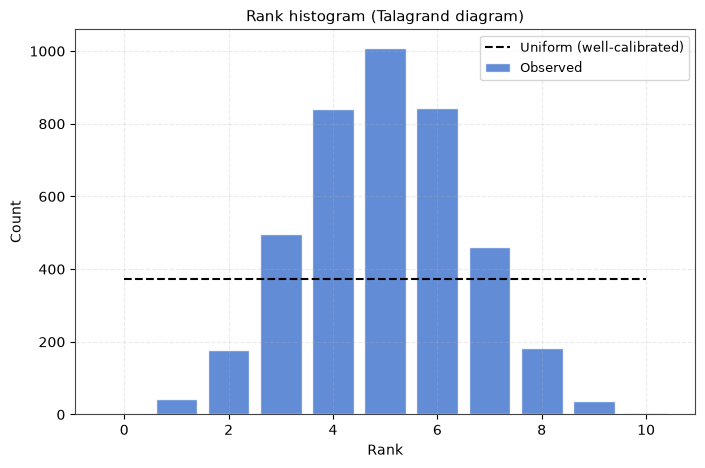

In [12]:
from aule.metrics import rank_histogram
from aule.plots import plot_rank_histogram

counts = rank_histogram(gt[0], ensemble)
fig, ax = plot_rank_histogram(counts)

## Diagnostic plots

This section covers `aule.plots.diagnostics`: the Taylor diagram, box/violin distribution comparisons, a flexible generic time series plot, and a pointwise error map.

### Taylor diagram

Summarizes correlation (angle) and normalized standard deviation (radius) for one or more predictions against a single ground truth — a classic at-a-glance comparison plot in climate model evaluation.

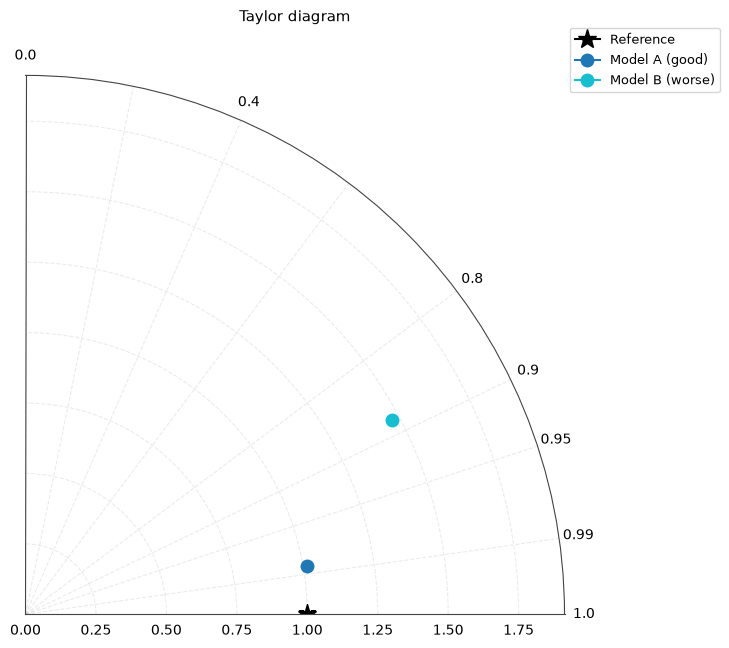

In [13]:
from aule.plots import plot_taylor_diagram

pred_a = gt + np.random.normal(0, 0.05, gt.shape)   # a relatively good model
pred_b = gt * 1.3 + np.random.normal(0, 0.2, gt.shape)  # a worse, biased model

fig, ax = plot_taylor_diagram(gt, [pred_a, pred_b], labels=['Model A (good)', 'Model B (worse)'])

### Box plot comparison

Compares the overall distribution of ground truth vs prediction values; `group_by_channel=True` breaks it down per channel.

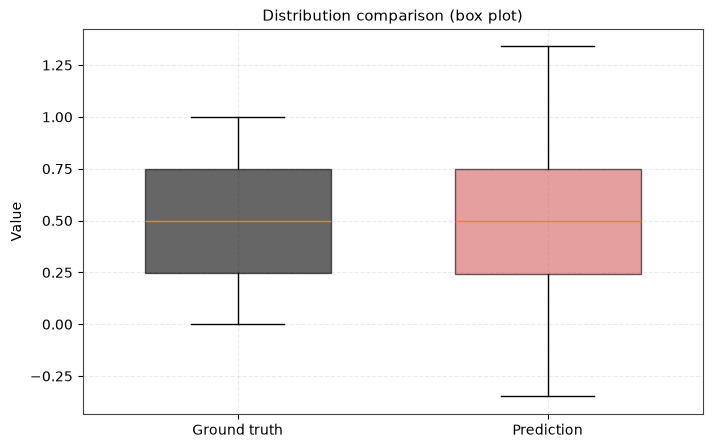

In [14]:
from aule.plots import plot_boxplot_comparison

fig, ax = plot_boxplot_comparison(gt, pred)

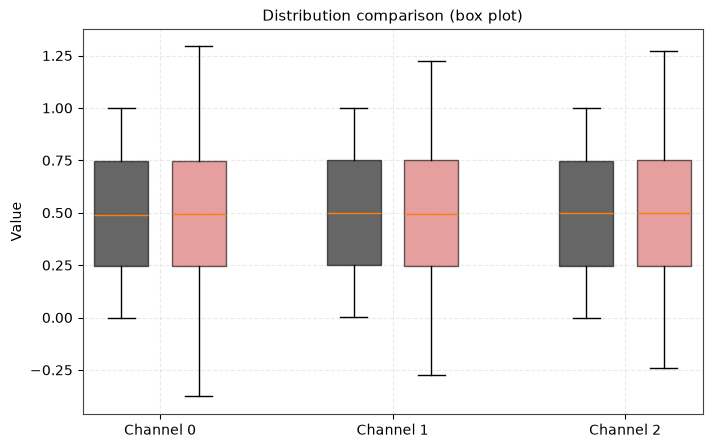

In [15]:
# multi-channel example
gt_multi = np.random.rand(8, 32, 32, 3)
pred_multi = gt_multi + np.random.normal(0, 0.1, gt_multi.shape)

fig, ax = plot_boxplot_comparison(gt_multi, pred_multi, group_by_channel=True)

### Violin plot comparison

An alternative to the box plot that also shows the distribution shape/density, not just the quartiles.

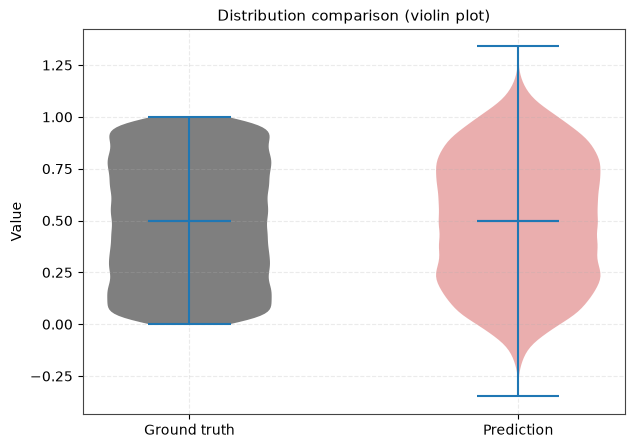

In [16]:
from aule.plots import plot_violin_comparison

fig, ax = plot_violin_comparison(gt, pred)

### Generic time series plot

Unlike `plot_temporal_trend`, this accepts any precomputed 1D arrays (not necessarily derived from the standard aule shapes) and supports optional shaded confidence bands per line.

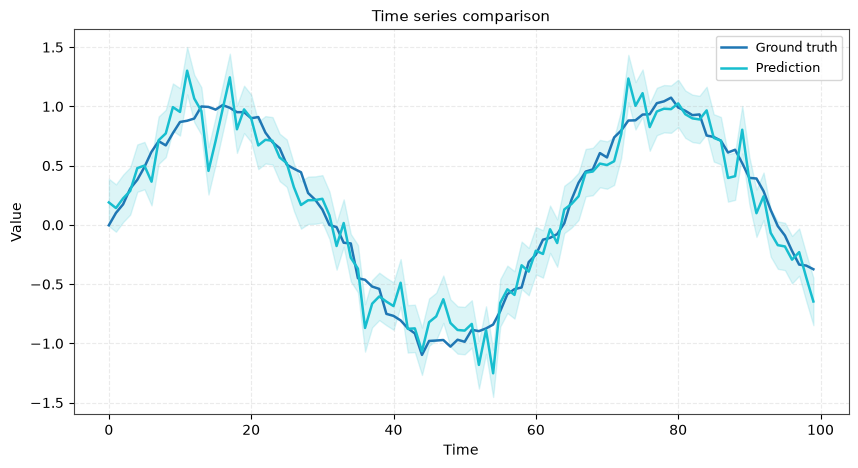

In [17]:
from aule.plots import plot_time_series

t = np.arange(100)
series_a = np.sin(t / 10) + np.random.normal(0, 0.05, 100)
series_b = np.sin(t / 10) + np.random.normal(0, 0.15, 100)
band_b = np.full(100, 0.2)

fig, ax = plot_time_series(
    [series_a, series_b],
    labels=['Ground truth', 'Prediction'],
    x=t,
    confidence_bands=[None, band_b],
)

### Pointwise error map

Shows the error for a *single* slice (unlike `plot_bias_map`, which averages over batch/time). `abs_error=True` (default) shows magnitude only; `abs_error=False` shows the signed error with a diverging colormap.

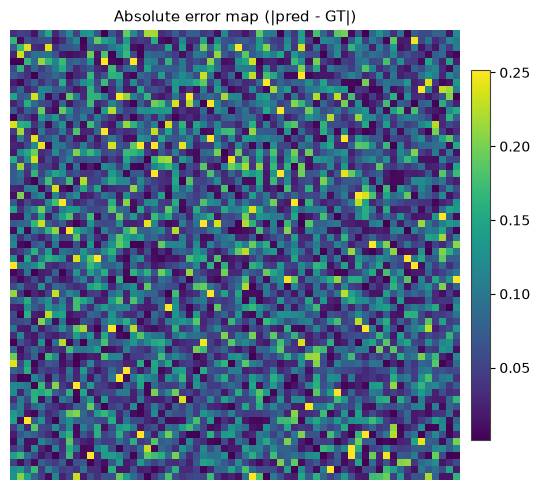

In [18]:
from aule.plots import plot_error_map

fig, ax = plot_error_map(gt[0], pred[0], abs_error=True)

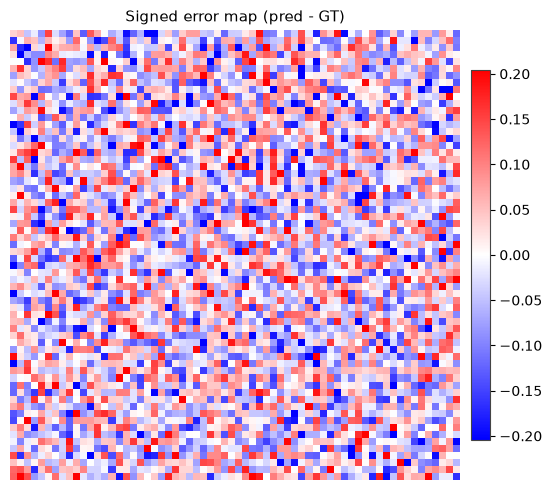

In [19]:
fig, ax = plot_error_map(gt[0], pred[0], abs_error=False)

## Classification plots

`plot_confusion_matrix` and `plot_reliability_diagram`, paired with `aule.metrics.classification` and the Brier score / PICP uncertainty metrics.

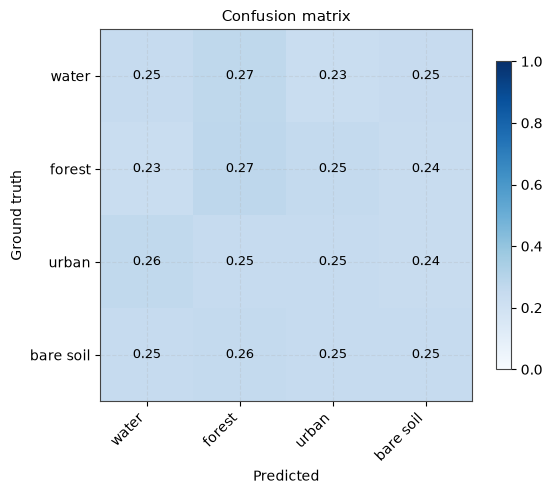

In [20]:
gt_labels = np.random.randint(0, 4, (64, 64, 1))
pred_labels = np.random.randint(0, 4, (64, 64, 1))

from aule.plots import plot_confusion_matrix

fig, ax = plot_confusion_matrix(gt_labels, pred_labels, num_classes=4,
                                 class_names=['water', 'forest', 'urban', 'bare soil'])

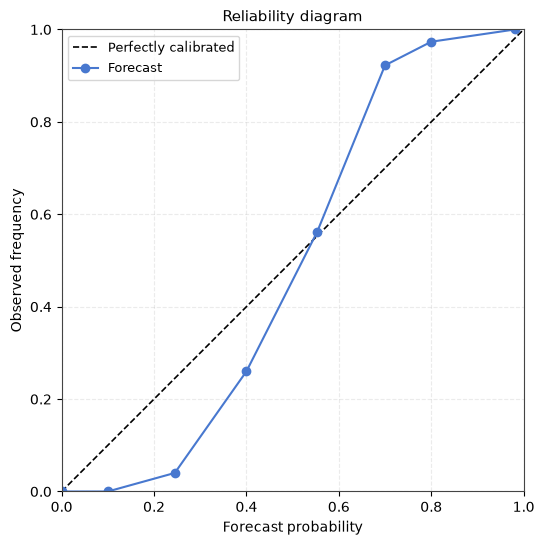

In [21]:
gt_single = gt[0]
ensemble_single = gt_single[np.newaxis] + np.random.normal(0, 0.1, (10, 64, 64, 1))

from aule.plots import plot_reliability_diagram

fig, ax = plot_reliability_diagram(gt_single, ensemble_single, threshold=0.6)